In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("sales_data_sample.csv",encoding='latin1')

In [5]:
print("First 5 rows of dataset: ")
print(df.head())

First 5 rows of dataset: 
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue

In [6]:
num_df = df.select_dtypes(include=['int64','float64']).copy()

In [8]:
num_df = num_df.dropna()

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

In [10]:
inertia = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state = 42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

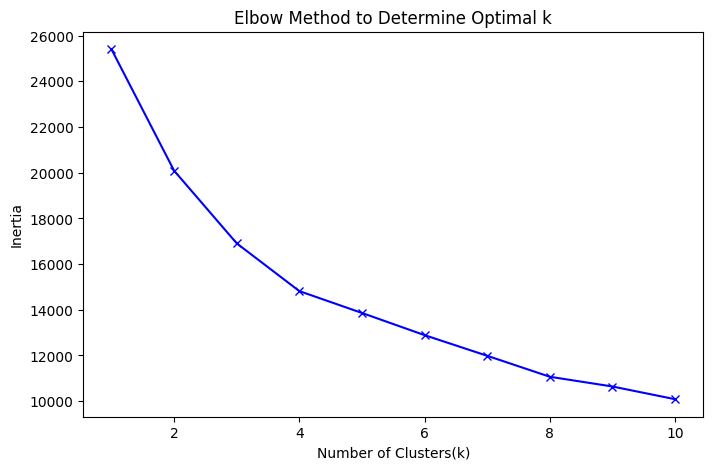

In [11]:
plt.figure(figsize=(8,5))
plt.plot(K,inertia,'bx-')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4,random_state = 42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

In [18]:
print("\nClustered Data Counts: ")
print(df['Cluster'].value_counts())


Clustered Data Counts: 
Cluster
1    948
3    734
2    663
0    478
Name: count, dtype: int64


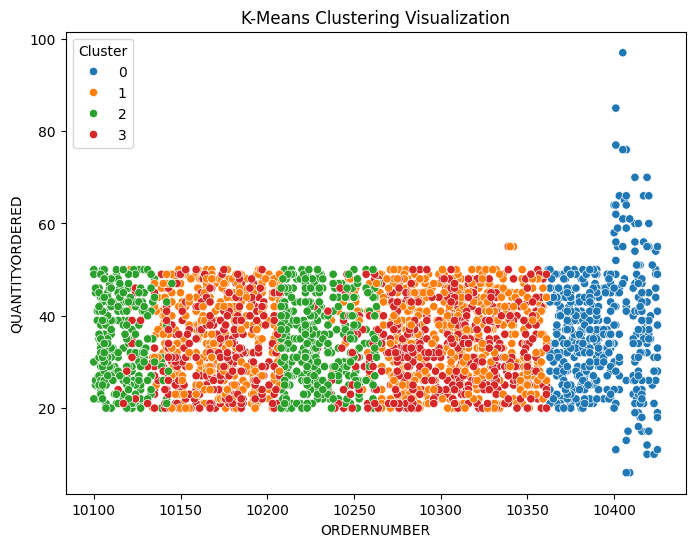

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=num_df.iloc[:, 0],
    y=num_df.iloc[:, 1],
    hue=df['Cluster'],
    palette='tab10'
)
plt.title("K-Means Clustering Visualization")
plt.xlabel(num_df.columns[0])
plt.ylabel(num_df.columns[1])
plt.show()